<a href="https://colab.research.google.com/github/ShreshthaPandey/JOSAA-collage-predictor/blob/main/clg_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [724]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [725]:
import zipfile

with zipfile.ZipFile("/content/archive (13).zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [726]:
import os

for year in range(2016, 2020):
    for round in range(1, 6):

        file = f"dataset/{year}_round_{round}.csv"

        if os.path.exists(file):
            os.remove(file)

In [727]:
import os

files = os.listdir("dataset")
files

['2020_round_2.csv',
 '2022.csv',
 '2025.csv',
 '2023_round_3.csv',
 '2022_round_5.csv',
 '2023.csv',
 '2020_round_1.csv',
 '2025_round_3.csv',
 '2023_round_6.csv',
 '2021_round_3.csv',
 '2018_round_6.csv',
 '2022_round_6.csv',
 '2025_round_2.csv',
 '2023_round_4.csv',
 '2025_round_6.csv',
 '2018_round_7.csv',
 '2017_round_6.csv',
 '2023_round_1.csv',
 '2025_round_1.csv',
 '2023_round_2.csv',
 '2025_round_5.csv',
 '2022_round_1.csv',
 '2022_round_2.csv',
 '2021_round_2.csv',
 '2024_round_5.csv',
 '2020_round_3.csv',
 '2022_round_3.csv',
 '2024.csv',
 '2024_round_3.csv',
 '2016_round_6.csv',
 '2024_round_1.csv',
 '2024_round_2.csv',
 '2021.csv',
 '2026_round_1.csv',
 '2020_round_5.csv',
 '2019_round_7.csv',
 '2022_round_4.csv',
 '2021_round_5.csv',
 '2021_round_6.csv',
 '2023_round_5.csv',
 '2020_round_6.csv',
 '2024_round_4.csv',
 '2020.csv',
 '2026.csv',
 '2019_round_6.csv',
 '2021_round_4.csv',
 '2021_round_1.csv',
 '2020_round_4.csv',
 '2025_round_4.csv',
 '2017_round_7.csv',
 'jee_

In [728]:
df = pd.read_csv("dataset/jee_exam_dynamics.csv")
df

,Year,Number_of_JEE_applicants_registered,Total_number_of_seats
0,2026,"15,38,468",67323
1,2025,"14,75,103",62853
2,2024,"14,15,110",57152
3,2023,"11,62,398",56874
4,2022,"10,26,799",54477
5,2021,"10,48,012",52453
6,2020,"11,74,103",50822
7,2019,"12,37,892",45235
8,2018,"11,35,084",37473
9,2017,"11,86,454",36268


In [729]:
df.drop([7 , 8 , 9 , 10])

,Year,Number_of_JEE_applicants_registered,Total_number_of_seats
0,2026,"15,38,468",67323
1,2025,"14,75,103",62853
2,2024,"14,15,110",57152
3,2023,"11,62,398",56874
4,2022,"10,26,799",54477
5,2021,"10,48,012",52453
6,2020,"11,74,103",50822


In [730]:
import os
import pandas as pd

for file in os.listdir("dataset"):
    if file.endswith(".csv"):

        path = os.path.join("dataset", file)
        df = pd.read_csv(path)

        print("\nFile:", file)
        print("Rows:", len(df))
        print("Columns:", list(df.columns))


File: 2020_round_2.csv
Rows: 9138
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2022.csv
Rows: 58880
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']


/tmp/ipykernel_3792/3293744942.py:8: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)



File: 2025.csv
Rows: 72189
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']

File: 2023_round_3.csv
Rows: 10404
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2022_round_5.csv
Rows: 9764
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2023.csv
Rows: 62865
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank', 'round']

File: 2020_round_1.csv
Rows: 9338
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2025_round_3.csv
Rows: 11982
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Opening Rank', 'Closing Rank']

File: 2023_round_6.csv
Rows: 10366
Columns: ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gende

In [731]:
import os
import pandas as pd

years = range(2020, 2027)

for year in years:
    all_data = []

    for file in os.listdir("dataset"):
        if file.startswith(f"{year}_round_") and file.endswith(".csv"):

            path = os.path.join("dataset", file)
            df = pd.read_csv(path)

            # Round number extract karo
            round_no = file.split("_")[2].replace(".csv", "")

            # New column
            df["round"] = round_no

            all_data.append(df)

    # Saare rounds merge
    if all_data:
        merged_df = pd.concat(all_data, ignore_index=True)

        # Save
        merged_df.to_csv(f"dataset/{year}.csv", index=False)

        print(f"{year}: {len(merged_df)} rows")

2020: 54614 rows
2021: 55590 rows
2022: 58880 rows
2023: 62865 rows
2024: 56918 rows
2025: 72189 rows
2026: 13292 rows


In [732]:
df0 = pd.read_csv("dataset/2020.csv")
df1 = pd.read_csv("dataset/2021.csv")
df2 = pd.read_csv("dataset/2022.csv")
df3 = pd.read_csv("dataset/2023.csv")
df3 = pd.read_csv("dataset/2024.csv")
df5 = pd.read_csv("dataset/2025.csv")
df6 = pd.read_csv("dataset/2026.csv")


/tmp/ipykernel_3792/917474916.py:6: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv("dataset/2025.csv")


In [733]:
df0.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN (PwD),Gender-Neutral,56P,56P,2
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2


In [734]:
df0.groupby("round").size()

,0
round,
1,9338
2,9138
3,9069
4,9045
5,9033
6,8991


In [735]:
import pandas as pd

all_data = []

for year in range(2020, 2027):
    file = f"dataset/{year}.csv"

    df = pd.read_csv(file)

    # Year column add karo
    df["year"] = year

    all_data.append(df)

# All years merge
final_df = pd.concat(all_data, ignore_index=True)

print(final_df.shape)
final_df.head()

(374348, 9)


/tmp/ipykernel_3792/812342895.py:8: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN (PwD),Gender-Neutral,56P,56P,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020


In [736]:
final_df.describe()

,round,year
count,374348.000000,374348.000000
mean,3.319652,2022.752289
std,1.707683,1.801642
min,1.000000,2020.000000
25%,2.000000,2021.000000
50%,3.000000,2023.000000
75%,5.000000,2024.000000
max,6.000000,2026.000000


In [737]:
final_df.isnull().sum()

,0
Institute,35
Academic Program Name,35
Quota,35
Seat Type,35
Gender,35
Opening Rank,35
Closing Rank,35
round,0
year,0


In [738]:
final_df[final_df["Academic Program Name"].isnull()]
final_df = final_df.dropna()

In [739]:
final_df.isnull().sum()

,0
Institute,0
Academic Program Name,0
Quota,0
Seat Type,0
Gender,0
Opening Rank,0
Closing Rank,0
round,0
year,0


In [740]:
final_df.shape

(374313, 9)

In [741]:
final_df.duplicated().sum()

np.int64(0)

In [742]:
df = final_df

In [743]:
df.shape

(374313, 9)

In [744]:
df.head(1)

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020


In [745]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374313 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              374313 non-null  object
 1   Academic Program Name  374313 non-null  object
 2   Quota                  374313 non-null  object
 3   Seat Type              374313 non-null  object
 4   Gender                 374313 non-null  object
 5   Opening Rank           374313 non-null  object
 6   Closing Rank           374313 non-null  object
 7   round                  374313 non-null  int64 
 8   year                   374313 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 28.6+ MB


In [746]:
df.describe()

,round,year
count,374313.000000,374313.000000
mean,3.319642,2022.752317
std,1.707685,1.801648
min,1.000000,2020.000000
25%,2.000000,2021.000000
50%,3.000000,2023.000000
75%,5.000000,2024.000000
max,6.000000,2026.000000


In [747]:
df.groupby('Opening Rank').size()

,0
Opening Rank,
3.0,1
4.0,1
5.0,1
6.0,1
7.0,2
...,...
99987,5
9999,6
99P,7


In [748]:
# df[df['Opening Rank'] == '99P']
df = df[
    ~(
        df["Opening Rank"].astype(str).str.contains("P", na=False) |
        df["Closing Rank"].astype(str).str.contains("P", na=False)
    )
]



In [749]:
df["Opening Rank"].dtype

dtype('O')

In [750]:
df["Closing Rank"].dtype

dtype('O')

In [751]:
df['Opening Rank'] = df['Opening Rank'].astype('float32')
df['Closing Rank'] = df['Closing Rank'].astype('float32')

/tmp/ipykernel_3792/2070766959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Opening Rank'] = df['Opening Rank'].astype('float32')
/tmp/ipykernel_3792/2070766959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Closing Rank'] = df['Closing Rank'].astype('float32')


In [752]:
df.sort_values("Opening Rank", ascending=False)

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
368756,"National Institute of Technology, Mizoram",Electronics and Communication Engineering (4 Y...,HS,OPEN,Female-only (including Supernumerary),1497038.0,1497038.0,1,2026
307948,"National Institute of Technology, Mizoram","Chemical Science and Technology (4 Years, Bach...",HS,OPEN,Gender-Neutral,1274910.0,1274910.0,2,2025
308000,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1210797.0,1210797.0,2,2025
273120,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1079883.0,1079883.0,2,2024
332079,"National Institute of Technology, Mizoram","Mathematics and Computing (4 Years, Bachelor o...",HS,OPEN,Female-only (including Supernumerary),1019344.0,1019344.0,1,2025
...,...,...,...,...,...,...,...,...,...
301009,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC,Gender-Neutral,1.0,31.0,2,2025
313061,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,ST (PwD),Gender-Neutral,1.0,1.0,6,2025
313058,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC (PwD),Gender-Neutral,1.0,1.0,6,2025
313056,Indian Institute of Technology Bombay,"Computer Science and Engineering (4 Years, Bac...",AI,SC,Gender-Neutral,1.0,31.0,6,2025


In [753]:
print("Opening Rank NaN:", df["Opening Rank"].isna().sum())
print("Closing Rank NaN:", df["Closing Rank"].isna().sum())

print("Opening Rank inf:", np.isinf(df["Opening Rank"]).sum())
print("Closing Rank inf:", np.isinf(df["Closing Rank"]).sum())

Opening Rank NaN: 0
Closing Rank NaN: 0
Opening Rank inf: 0
Closing Rank inf: 0


In [754]:
df = df[~(np.isinf(df["Closing Rank"]))]
df = df[~(np.isinf(df["Opening Rank"]))]

In [755]:
df['Closing Rank'].max()

1497038.0

In [756]:
df["Opening Rank"] = df["Opening Rank"].astype('int32')
df["Closing Rank"] = df["Closing Rank"].astype('int32')
df['round'] = df['round'].astype('int16')
df['year'] = df['year'].astype('int16')

In [757]:
df['Closing Rank'].max()

1497038

In [758]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366914 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              366914 non-null  object
 1   Academic Program Name  366914 non-null  object
 2   Quota                  366914 non-null  object
 3   Seat Type              366914 non-null  object
 4   Gender                 366914 non-null  object
 5   Opening Rank           366914 non-null  int32 
 6   Closing Rank           366914 non-null  int32 
 7   round                  366914 non-null  int16 
 8   year                   366914 non-null  int16 
dtypes: int16(2), int32(2), object(5)
memory usage: 21.0+ MB


In [759]:
df.shape

(366914, 9)

In [760]:
df.groupby("Opening Rank").size()

,0
Opening Rank,
1,211
2,158
3,207
4,182
5,194
...,...
1019344,1
1079883,1
1210797,1


In [761]:
df.groupby("Quota").size()

,0
Quota,
AI,148160
AI,6028
GO,1181
GO,37
HS,95205
HS,3291
JK,2579
JK,80
LA,432


In [762]:
df.groupby("Institute").size().sort_values(ascending=False)


,0
Institute,
"National Institute of Technology, Rourkela",13917
Indian Institute of Technology Kharagpur,11162
"National Institute of Technology, Warangal",9180
National Institute of Technology Raipur,9140
"Dr. B R Ambedkar National Institute of Technology, Jalandhar",8892
...,...
"National Institute of Electronics and Information Technology, Srinagar",8
"National Institute of Electronics and Information Technology, Agartala",7
"National Institute of Electronics and Information Technology, Imphal",6


In [763]:
max_iit_crl = df[(df['Seat Type'] == 'OPEN') & (df['Quota'] == 'AI')]['Closing Rank'].max()
print("Max IIT CRL:", max_iit_crl)

# Max CRL Rank for NITs/IIITs/GFTIs (Home State and Other State Quotas)
max_nit_crl = df[(df['Seat Type'] == 'OPEN') & (df['Quota'].isin(['HS', 'OS']))]['Closing Rank'].max()
print("Max NIT/IIIT CRL:", max_nit_crl)

Max IIT CRL: 125271
Max NIT/IIIT CRL: 1368129


In [764]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


Your predictor works for    →  Ranks 1 to ~40,000

Students above rank 40,000  →  "No JoSAA colleges available"

                               You can show this message to them

In [765]:
df[df['Opening Rank'] < 0]

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year


In [766]:

df = df[df['Closing Rank'] > 0]
df = df[df['Opening Rank'] > 0]

In [767]:
# Check if any opening rank > closing rank (data error)
bad_rows = df[df['Opening Rank'] > df['Closing Rank']]
print(f"Bad rows: {len(bad_rows)}")

Bad rows: 0


In [768]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020


In [769]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


In [770]:
# Check which rows have suspiciously high ranks
bad = df[df['Closing Rank'] > 100000]
print(f"Bad rows count: {len(bad)}")
print(bad['year'].value_counts())
print(bad.head(5))

Bad rows count: 5618
year
2025    1252
2024     895
2021     858
2023     830
2020     813
2022     772
2026     198
Name: count, dtype: int64
                                      Institute  \
3512  National Institute of Technology Agartala   
3513  National Institute of Technology Agartala   
3528  National Institute of Technology Agartala   
3529  National Institute of Technology Agartala   
3548  National Institute of Technology Agartala   

                                  Academic Program Name Quota Seat Type  \
3512  Biotechnology and Biochemical Engineering (4 Y...    HS      OPEN   
3513  Biotechnology and Biochemical Engineering (4 Y...    HS      OPEN   
3528  Chemical Engineering (4 Years, Bachelor of Tec...    HS      OPEN   
3529  Chemical Engineering (4 Years, Bachelor of Tec...    HS      OPEN   
3548  Chemistry (5 Years, Bachelor of Science and Ma...    HS      OPEN   

                                     Gender  Opening Rank  Closing Rank  \
3512                    

In [771]:
df.describe()

,Opening Rank,Closing Rank,round,year
count,3.669140e+05,3.669140e+05,366914.000000,366914.000000
mean,1.135986e+04,1.414337e+04,3.318884,2022.768308
std,3.052512e+04,4.031729e+04,1.707595,1.797408
min,1.000000e+00,1.000000e+00,1.000000,2020.000000
25%,1.319000e+03,1.574000e+03,2.000000,2021.000000
50%,4.044000e+03,4.845000e+03,3.000000,2023.000000
75%,1.067500e+04,1.285675e+04,5.000000,2024.000000
max,1.497038e+06,1.497038e+06,6.000000,2026.000000


In [772]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'round', 'year'],
      dtype='object')

In [773]:
df.shape

(366914, 9)

In [774]:
df['year'].describe()

,year
count,366914.000000
mean,2022.768308
std,1.797408
min,2020.000000
25%,2021.000000
50%,2023.000000
75%,2024.000000
max,2026.000000


In [775]:
# # Save the cleaned dataframe to a new CSV file
# df.to_csv('josaa_cleaned.csv', index=False)

# # Download it
# from google.colab import files
# files.download('josaa_cleaned.csv')

# print(f"✅ Saved and downloading!")
# print(f"Shape: {df.shape}")
# print(f"Columns: {df.columns.tolist()}")

In [776]:
df.head()


,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,round,year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,7182,9202,2,2020
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),13212,15064,2,2020
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1297,1589,2,2020
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),2655,2819,2,2020
5,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,3057,3823,2,2020


In [777]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 366914 entries, 0 to 374347
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Institute              366914 non-null  object
 1   Academic Program Name  366914 non-null  object
 2   Quota                  366914 non-null  object
 3   Seat Type              366914 non-null  object
 4   Gender                 366914 non-null  object
 5   Opening Rank           366914 non-null  int32 
 6   Closing Rank           366914 non-null  int32 
 7   round                  366914 non-null  int16 
 8   year                   366914 non-null  int16 
dtypes: int16(2), int32(2), object(5)
memory usage: 21.0+ MB


In [782]:
df['Year'].info()
df = df.rename(columns={'year' : 'Year',
                   })


<class 'pandas.core.series.Series'>
Index: 366914 entries, 0 to 374347
Series name: Year
Non-Null Count   Dtype
--------------   -----
366914 non-null  int16
dtypes: int16(1)
memory usage: 3.5 MB


In [783]:
df["Year"].value_counts()

,count
Year,
2025,71414
2023,62083
2022,58321
2024,55961
2021,53416
2020,52634
2026,13085


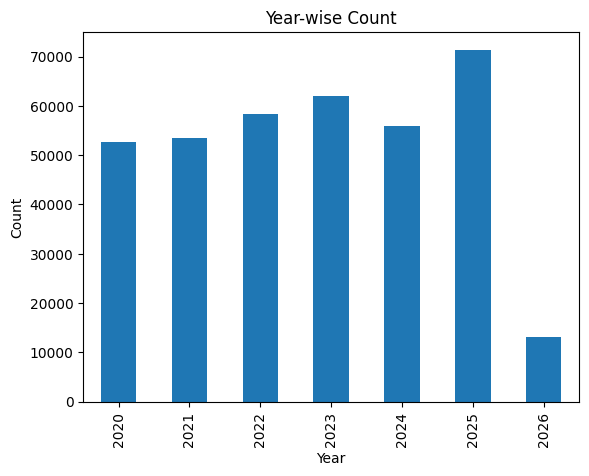

In [785]:
import matplotlib.pyplot as plt

df["Year"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Year-wise Count")
plt.show()

In [786]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'round', 'Year'],
      dtype='object')

In [787]:
df = df.rename(columns={'round' : 'Round'})

In [788]:
df['Round'].value_counts()

,count
Round,
1,75434
2,60896
3,60549
4,60464
5,60410
6,49161


In [789]:
df = df[df['Round'] <6]
df.shape

(317753, 9)

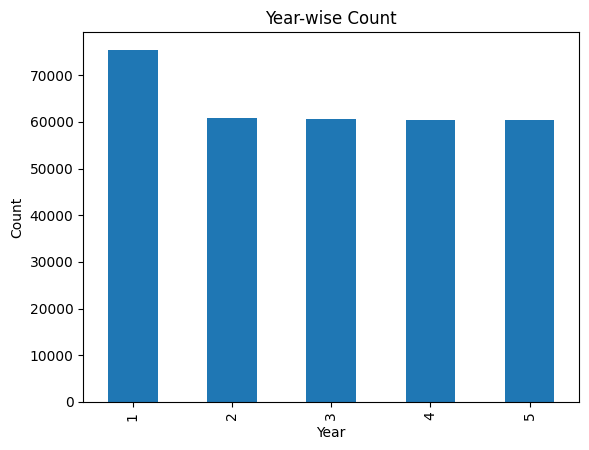

In [790]:
import matplotlib.pyplot as plt

df["Round"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Year-wise Count")
plt.show()

In [791]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [793]:
df['Opening Rank'].value_counts().sort_index(ascending=False)
df['Closing Rank'].value_counts().sort_index(ascending=False)

,count
Closing Rank,
1497038,1
1368129,2
1317736,1
1314967,4
1294100,1
...,...
5,112
4,125
3,143


/tmp/ipykernel_3792/3841245975.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


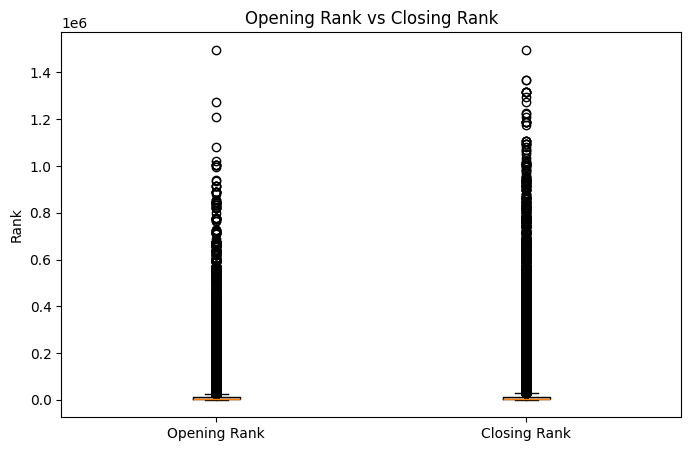

In [792]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [df["Opening Rank"], df["Closing Rank"]],
    labels=["Opening Rank", "Closing Rank"]
)

plt.ylabel("Rank")
plt.title("Opening Rank vs Closing Rank")
plt.show()

In [794]:
df['Closing Rank'].info()
df['Closing Rank'].max()
df['Closing Rank'].min()

<class 'pandas.core.series.Series'>
Index: 317753 entries, 0 to 374347
Series name: Closing Rank
Non-Null Count   Dtype
--------------   -----
317753 non-null  int32
dtypes: int32(1)
memory usage: 3.6 MB


1

In [795]:
df['Opening Rank'].info()
df['Opening Rank'].max()
df['Opening Rank'].min()

<class 'pandas.core.series.Series'>
Index: 317753 entries, 0 to 374347
Series name: Opening Rank
Non-Null Count   Dtype
--------------   -----
317753 non-null  int32
dtypes: int32(1)
memory usage: 3.6 MB


1

In [796]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [797]:
df['Gender'].value_counts()

,count
Gender,
Gender-Neutral,190778
Female-only (including Supernumerary),113890
Gender-Neutral,8390
Female-only (including Supernumerary),4695


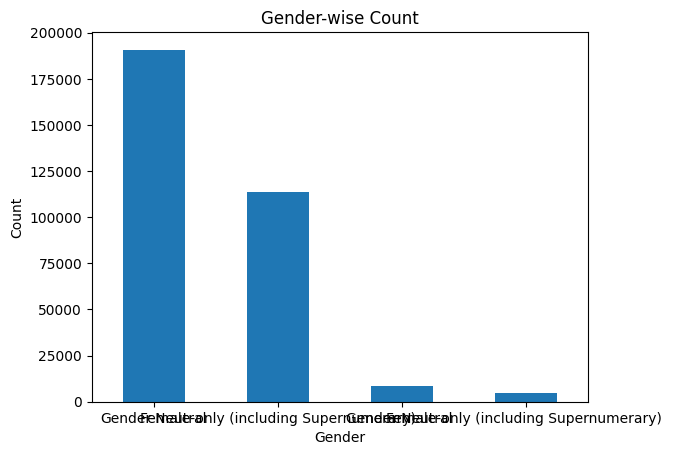

In [798]:
import matplotlib.pyplot as plt

gender_count = df["Gender"].value_counts()

gender_count.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender-wise Count")
plt.xticks(rotation=0)
plt.show()

In [799]:
df["Gender"] = df["Gender"].str.strip()

In [800]:
df['Gender'].value_counts()

,count
Gender,
Gender-Neutral,199168
Female-only (including Supernumerary),118585


In [801]:
df['Seat Type'].value_counts()

,count
Seat Type,
OPEN,61797
OBC-NCL,56330
SC,55907
EWS,51101
ST,47107
OPEN (PwD),17120
OBC-NCL (PwD),9262
EWS (PwD),2868
OPEN,2566


In [802]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [807]:
df['Quota'].value_counts()


,count
Quota,
AI,127676
OS,91418
HS,81963
AI,6028
OS,3635
HS,3291
JK,2218
GO,1023
LA,370


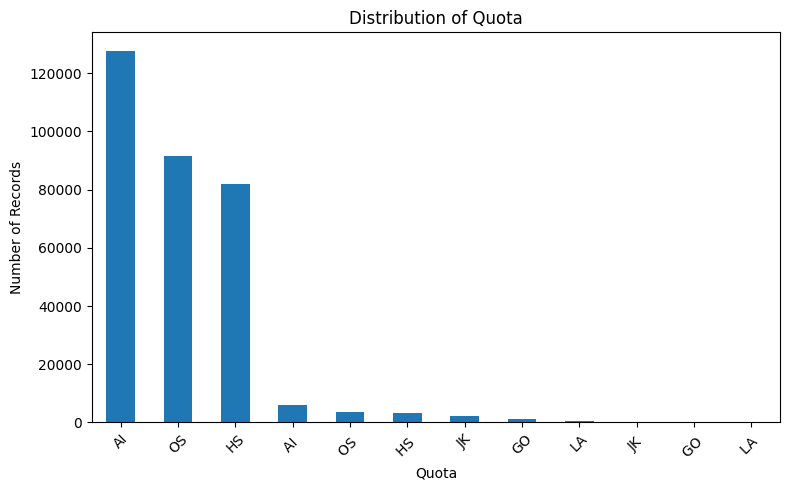

In [804]:
import matplotlib.pyplot as plt

quota_count = df['Quota'].value_counts()

quota_count.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Quota')
plt.ylabel('Number of Records')
plt.title('Distribution of Quota')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [808]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [817]:
df['Academic Program Name'].value_counts().sort_values()


,count
Academic Program Name,
"B.Tech. (Food Engineering and Technology) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",3
"B.Tech. (Elctrical Engineering) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech. (Civil Engineering) - MBA (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech (Mathematics and Computing) - MBA in Digital Business Management (IIM Bodh Gaya) (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
"B.Tech (Chemical Science and Technology) - MBA in Hospital and Health Care Management (IIM Bodh Gaya) (5 Years, Bachelor of Technology and MBA (Dual Degree))",4
...,...
"Electrical Engineering (4 Years, Bachelor of Technology)",20662
"Civil Engineering (4 Years, Bachelor of Technology)",26662
"Mechanical Engineering (4 Years, Bachelor of Technology)",29088


In [813]:
df.columns

Index(['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender',
       'Opening Rank', 'Closing Rank', 'Round', 'Year'],
      dtype='object')

In [816]:
df['Institute'].value_counts().sort_values()

,count
Institute,
"National Institute of Electronics and Information Technology, Calicut",6
"National Institute of Electronics and Information Technology, Imphal",6
"National Institute of Electronics and Information Technology, Kohima",6
"National Institute of Electronics and Information Technology, Agartala",7
"National Institute of Electronics and Information Technology, Srinagar",8
...,...
"Dr. B R Ambedkar National Institute of Technology, Jalandhar",7702
National Institute of Technology Raipur,7881
"National Institute of Technology, Warangal",7958
